# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** CRISTIAN JUAN CARLOS PAZ CONDE

* **matrícula:** A01840610

------------

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++


La rotación de personal (employee attrition) es la salida de empleados de una empresa, ya sea voluntaria o involuntariamente. Este problema puede afectar la productividad y generar costos adicionales de contratación y capacitación. Mediante análisis de datos, es posible identificar factores como salario, satisfacción laboral, educación o distancia al trabajo que influyen en la decisión de un empleado de abandonar la organización.




++++++++ Termina la sección de agregar texto. +++++++++++

In [33]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Ocultar FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

# Ocultar UserWarning
warnings.filterwarnings("ignore", category=UserWarning)

* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [12]:
path = "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a)  Realiza los análisis descriptivos y/o gráficos que creas adecuados, para identificar 4 factores que se deben eliminar desde un inicio.**

**b) Con base a tu análisis anterior, indica cuáles son estas 4 variables y la justificación de por qué se pueden eliminar.**

**c) Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



Tamaño del DataFrame original: (1470, 35)

Distribución de EmployeeCount:
EmployeeCount
1    1470
Name: count, dtype: int64


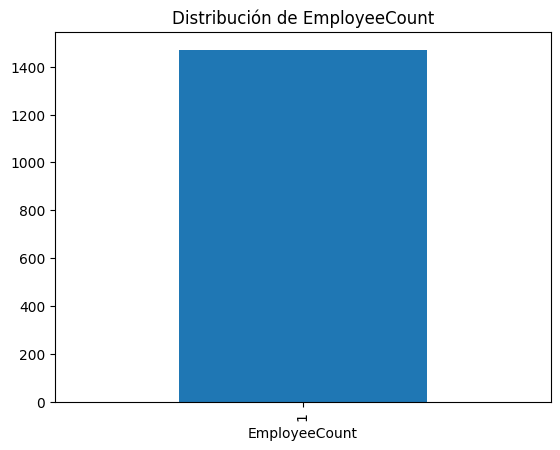


Distribución de Over18:
Over18
Y    1470
Name: count, dtype: int64


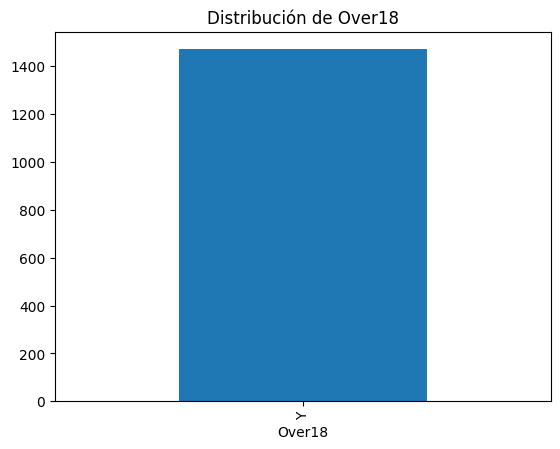


Distribución de StandardHours:
StandardHours
80    1470
Name: count, dtype: int64


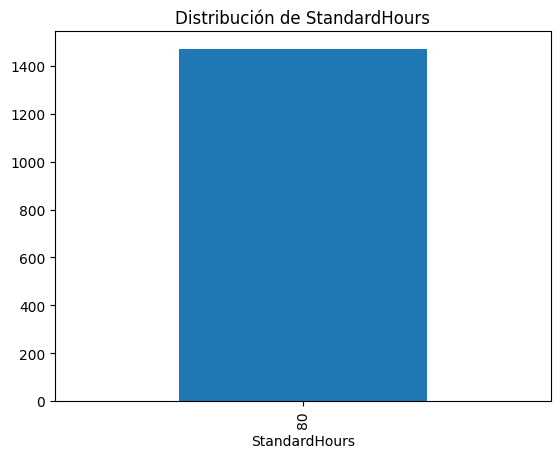

Tamaño del nuevo DataFrame: (1470, 31)


In [18]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

print("Tamaño del DataFrame original:", data.shape)

data.describe(include='all').T

# Variables constantes
variables_constantes = ['EmployeeCount', 'Over18', 'StandardHours']

for col in variables_constantes:

    print(f"\nDistribución de {col}:")
    print(data[col].value_counts())

    # Gráfico
    data[col].value_counts().plot(
        kind='bar',
        title=f'Distribución de {col}'
    )

    plt.show()


# =========================================================
# b) Variables eliminadas y justificación
# =========================================================

"""
1. EmployeeCount:
   Tiene un único valor para todos los registros.

2. Over18:
   Todos los empleados tienen el valor 'Y'.

3. StandardHours:
   La cantidad de horas es igual para todos los empleados.

4. EmployeeNumber:
   Es únicamente un identificador de empleado y no aporta
   información predictiva.
"""

# =========================================================
# c) Crear nuevo DataFrame sin las variables eliminadas
# =========================================================

df = data.drop(columns=[
    'EmployeeCount',
    'Over18',
    'StandardHours',
    'EmployeeNumber'
])


# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes.**

#### **Realiza los análisis que creas adecuados para clasificar cada una de nuestras variables según su tipo.**

#### **Debes analizar todas las variables de entrada y también la de salida.**


+++++++++ Inicia la sección de agregar texto: ++++++++++++

### a) Variables numéricas:

- **Número de variables:** 14

- **Nombre de las variables:**
`Age`, `DailyRate`, `DistanceFromHome`, `HourlyRate`, `MonthlyIncome`,
`MonthlyRate`, `NumCompaniesWorked`, `PercentSalaryHike`,
`TotalWorkingYears`, `TrainingTimesLastYear`, `YearsAtCompany`,
`YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`

---

### b) Variables ordinales:

- **Número de variables:** 9

- **Nombre de las variables:**
`Education`, `EnvironmentSatisfaction`, `JobInvolvement`,
`JobSatisfaction`, `PerformanceRating`, `RelationshipSatisfaction`,
`WorkLifeBalance`, `JobLevel`, `StockOptionLevel`

#### NOTA:
Considera aquí las 7 variables que se indican en la página de Kaggle e incluye también las variables "Level".

---

### c) Variables binarias:

- **Número de variables:** 3

- **Nombre de las variables:**
`Attrition`, `Gender`, `OverTime`

---

### d) Variables nominales:

- **Número de variables:** 8

- **Nombre de las variables:**
`BusinessTravel`, `Department`, `EducationField`, `JobRole`,
`MaritalStatus`

++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

#### **Como hemos comentado previamente, la forma en que se particiona el conjunto de datos es un aspecto fundamental dentro del área de aprendizaje automático. Ahora que ya también conoces la técnica de Validación Cruzada, explica cómo puede utilizarse cada una de las particiones iniciales indicadas y cuáles son los pros y contras de utilizar cada una de ellas. Se desea comparar la partición inicial de Train+Validation, en contraste con la partición Train+Validation+Test.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

### a) Partición Train+Validation:

- **Pros:**
  - Permite entrenar y validar el modelo utilizando validación cruzada.
  - Aprovecha mejor la cantidad de datos disponibles.
  - Reduce el riesgo de sobreajuste durante el entrenamiento.
  - Es útil cuando el conjunto de datos es pequeño.

- **Contras:**
  - No existe un conjunto independiente final para evaluar el desempeño real del modelo.
  - Puede generar estimaciones demasiado optimistas.
  - Existe mayor riesgo de fuga de información entre entrenamiento y validación.

---

### b) Partición Train+Validation+Test:

- **Pros:**
  - Permite evaluar el modelo con datos completamente nuevos mediante el conjunto de prueba.
  - Ofrece una medición más realista del desempeño final.
  - Reduce el riesgo de sobreajuste al proceso de validación.
  - Es el enfoque más recomendado en proyectos de aprendizaje automático.

- **Contras:**
  - Se reduce la cantidad de datos disponibles para entrenamiento.
  - Puede afectar el rendimiento cuando el dataset es pequeño.
  - Requiere mayor tiempo computacional si además se utiliza validación cruzada.

++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [19]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [21]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# Crear objeto LabelEncoder
label_encoder = LabelEncoder()

# Ajustar SOLO con datos de entrenamiento
label_encoder.fit(ytrain.values.ravel())

# Transformar variables
ytrainT = pd.DataFrame(
    label_encoder.transform(ytrain.values.ravel()),
    columns=['Attrition']
)

yvalT = pd.DataFrame(
    label_encoder.transform(yval.values.ravel()),
    columns=['Attrition']
)

ytestT = pd.DataFrame(
    label_encoder.transform(ytest.values.ravel()),
    columns=['Attrition']
)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n',
      ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la proporción de datos de cada clase obtenida, indica si podemos considerar que tenemos un problema de datos desbalanceados.**

**e) Con base a esta información, ¿cuál será el umbral del modelo base (baseline) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**




++++++++ Inicia la sección de agregar texto: ++++++++++++

## **SOLUCIÓN PARA EL PROFESOR:**

### b)
De acuerdo con la documentación de Sklearn, la transformación `LabelEncoder` se recomienda principalmente para variables objetivo (*target labels*), es decir, para la variable de salida `y`, y no para las variables de entrada.

---

### c)
En el contexto del problema:

- **0 (NO):** El empleado permanece en la empresa.
- **1 (YES):** El empleado abandonó la empresa (rotación de personal).

---

### d)
Sí, existe un problema de datos desbalanceados, ya que la cantidad de empleados que permanecen en la empresa es considerablemente mayor que la cantidad de empleados que abandonan la organización.

---

### e)
El modelo base (*baseline*) será la proporción de la clase mayoritaria.
Por lo tanto, si aproximadamente el 84% de los empleados pertenecen a la clase “No Attrition”, entonces el modelo deberá superar aproximadamente una exactitud (*accuracy*) de **84%** para considerarse mejor que una predicción trivial.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Incluye algunos comentarios sobre los resultados y gráficos obtenidos.**


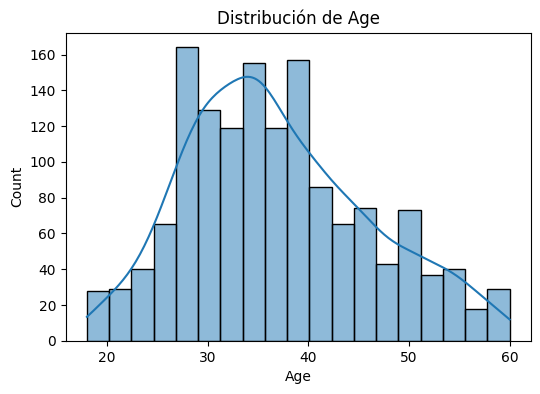

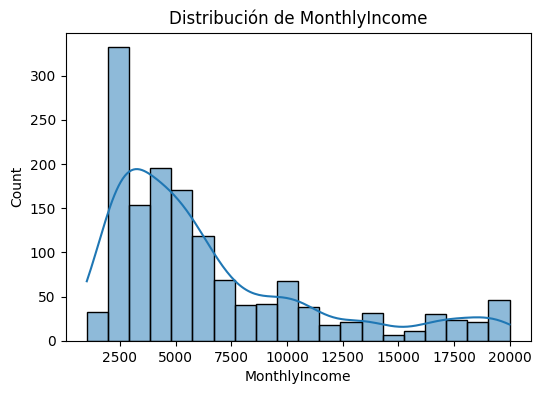

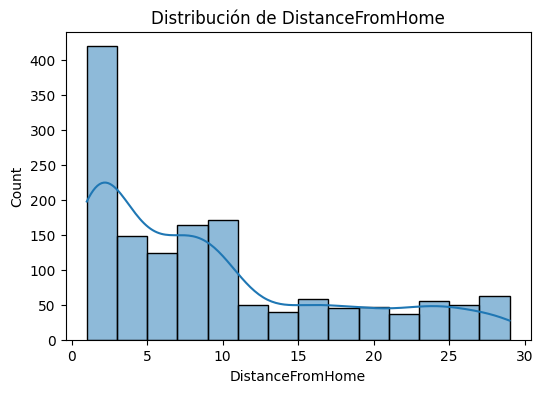

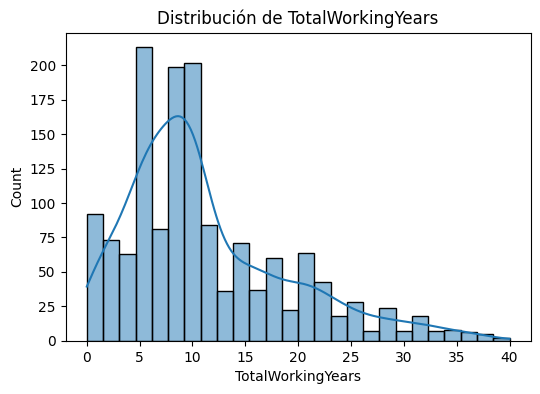

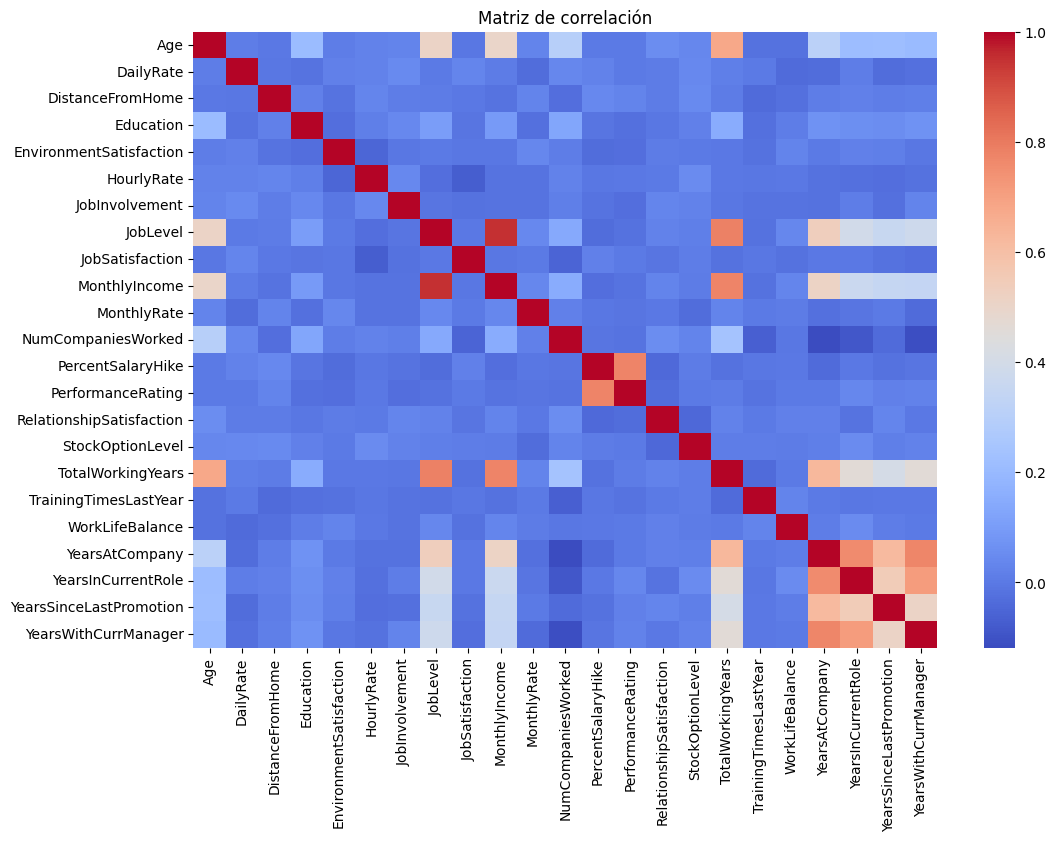

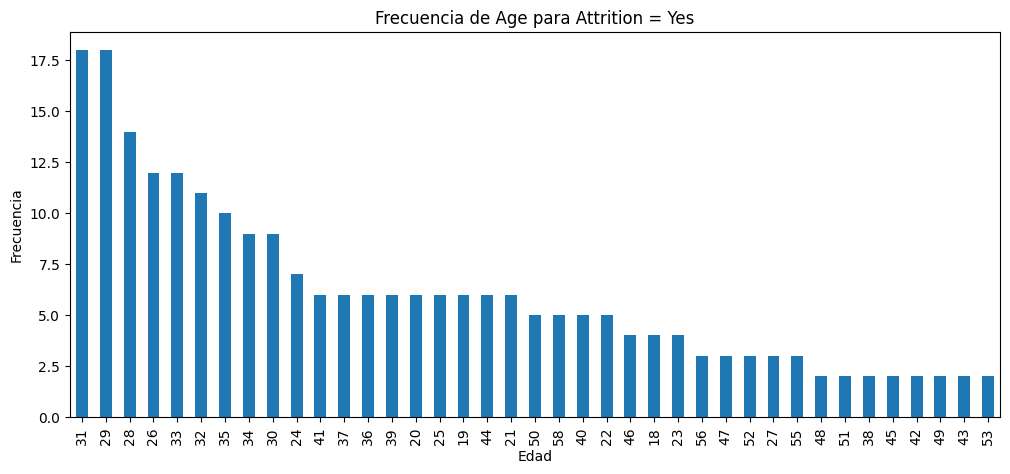

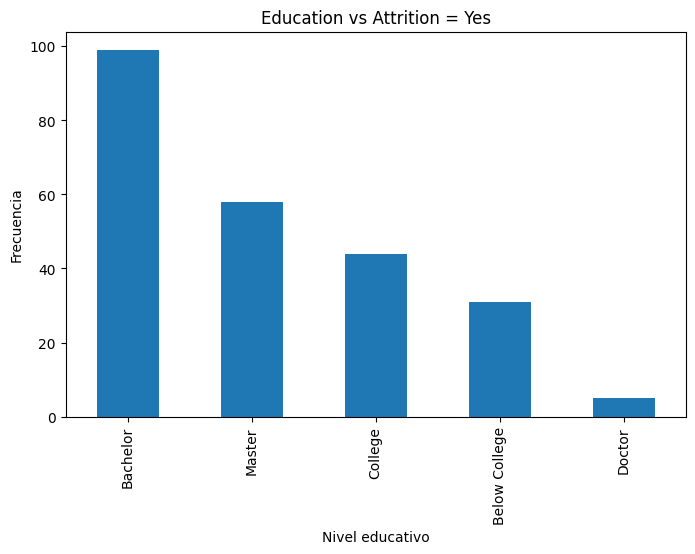

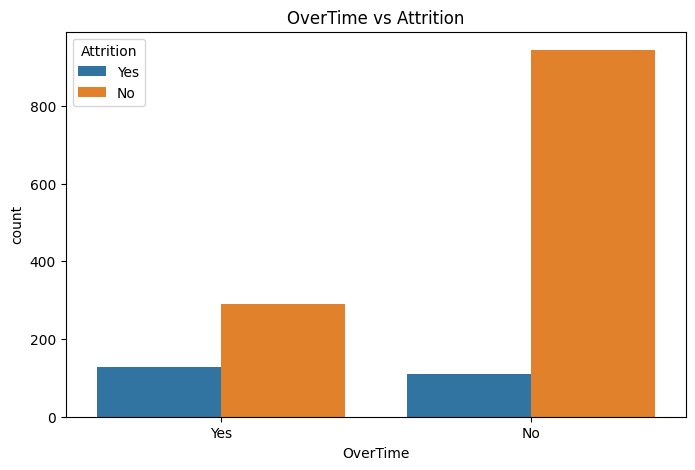

In [25]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

# Distribución de variables numéricas
variables_numericas = [
    'Age',
    'MonthlyIncome',
    'DistanceFromHome',
    'TotalWorkingYears'
]

for col in variables_numericas:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribución de {col}')

    plt.show()


# Matriz de correlación
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title('Matriz de correlación')

plt.show()



# b) Gráfico age-attrition[yes]

attrition_yes = df[df['Attrition'] == 'Yes']

plt.figure(figsize=(12,5))

attrition_yes['Age'].value_counts() \
    .sort_values(ascending=False) \
    .plot(kind='bar')

plt.title('Frecuencia de Age para Attrition = Yes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

# c) Gráfico education-attrition[yes]

education_labels = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

education_attrition = (
    attrition_yes['Education']
    .value_counts()
    .sort_index()
)

education_attrition.index = [
    education_labels[i]
    for i in education_attrition.index
]

plt.figure(figsize=(8,5))

education_attrition.sort_values(ascending=False) \
    .plot(kind='bar')

plt.title('Education vs Attrition = Yes')
plt.xlabel('Nivel educativo')
plt.ylabel('Frecuencia')

plt.show()

# d) [gráfico opcional]

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title('OverTime vs Attrition')

plt.show()



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) Comentarios sobre los incisos anteriores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

- Las variables numéricas presentan diferentes distribuciones y escalas, por lo que algunas podrían requerir normalización o estandarización antes de entrenar modelos de aprendizaje automático.

- En la matriz de correlación se observan relaciones entre variables relacionadas con experiencia laboral y permanencia en la empresa.

- El gráfico de edades muestra que la rotación de personal ocurre con mayor frecuencia en empleados jóvenes.

- En el análisis entre Education y Attrition se observa que los niveles Bachelor y College concentran la mayor cantidad de empleados que abandonan la empresa.

- El gráfico opcional sugiere que los empleados que realizan horas extra (OverTime) presentan una mayor tendencia a abandonar la organización.

++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo.**



In [26]:
from sklearn.preprocessing import StandardScaler

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numericas_pipeline_nombres = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# ORDINALES:

catOrd_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

catOrd_pipeline_nombres = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'JobLevel',
    'StockOptionLevel'
]


# BINARIAS:

catBin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

catBin_pipeline_nombres = [
    'Gender',
    'OverTime'
]

# NOMINALES:

catNom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

catNom_pipeline_nombres = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
]




columnasTransformer = ColumnTransformer([

    ('num',
     numericas_pipeline,
     numericas_pipeline_nombres),

    ('ord',
     catOrd_pipeline,
     catOrd_pipeline_nombres),

    ('bin',
     catBin_pipeline,
     catBin_pipeline_nombres),

    ('nom',
     catNom_pipeline,
     catNom_pipeline_nombres)
])




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [27]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados.**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados. En esta y próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera el problema y obtener mejores desempeños.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold", puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.883 (0.019)
>> LASSO 0.888 (0.018)
>> RIDGE 0.886 (0.016)
>> EN 0.888 (0.017)
>> kNN 0.855 (0.008)


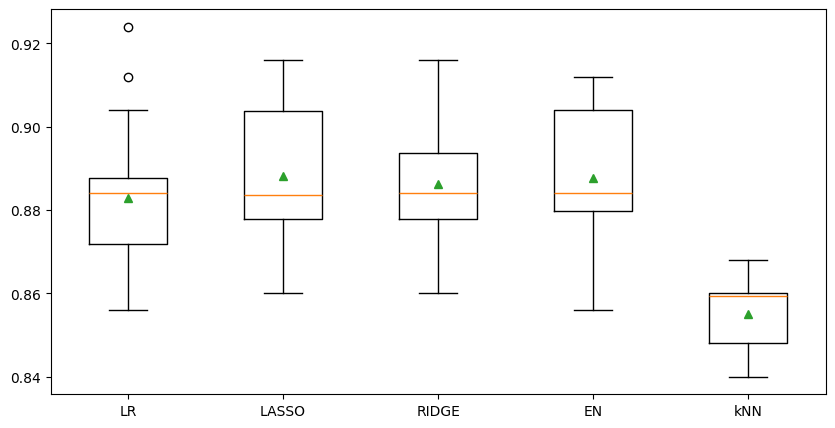

In [34]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás cambiarlo

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():

    modelos, nombres = list(), list()


    # =========================================================
    # LR - Regresión Logística sin regularización
    # =========================================================

    modelos.append(
        LogisticRegression(
            C=1e10,
            solver='lbfgs',
            max_iter=5000,
            random_state=1
        )
    )

    nombres.append('LR')


    # =========================================================
    # LASSO - Regularización L1
    # =========================================================

    modelos.append(
        LogisticRegression(
            l1_ratio=1,
            solver='saga',
            C=1.0,
            max_iter=5000,
            random_state=1
        )
    )

    nombres.append('LASSO')


    # =========================================================
    # RIDGE - Regularización L2
    # =========================================================

    modelos.append(
        LogisticRegression(
            l1_ratio=0,
            solver='lbfgs',
            C=1.0,
            max_iter=5000,
            random_state=1
        )
    )

    nombres.append('RIDGE')


    # =========================================================
    # ELASTIC NET
    # =========================================================

    modelos.append(
        LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,
            C=1.0,
            max_iter=5000,
            random_state=1
        )
    )

    nombres.append('EN')


    # =========================================================
    # KNN
    # =========================================================

    modelos.append(
        KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            metric='minkowski'
        )
    )

    nombres.append('kNN')

    return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay varias maneras de entrenarlo pero por el momento utilicemos la siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados.


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo y por qué. ¿Alguno quedó subentrenado?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

- Todos los modelos lograron superar el baseline aproximado de 84%, por lo que no presentan subentrenamiento.

- Los modelos de regresión logística obtuvieron resultados muy similares, con exactitudes cercanas al 88%.

- El modelo LASSO obtuvo el mejor desempeño promedio, alcanzando aproximadamente 88.8% de accuracy.

- El modelo RIDGE presentó una desviación estándar ligeramente menor, mostrando mayor estabilidad entre las particiones de validación cruzada.

- La validación cruzada RepeatedStratifiedKFold permitió obtener resultados más robustos y confiables.

- Considero que el mejor modelo es LASSO, ya que obtuvo la mayor exactitud promedio y además ayuda a reducir variables menos relevantes mediante regularización L1.

- Ningún modelo quedó subentrenado debido a que todos superaron claramente el desempeño base esperado.

++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [35]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++




pipeline_malla = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('modelo', LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=5000,
        random_state=1
    ))
])


# Hiperparámetros
param_grid = {
    'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100]
}


# Validación cruzada
cv_malla = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=7
)


# Grid Search
resultado_malla = GridSearchCV(
    estimator=pipeline_malla,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv_malla,
    return_train_score=True,
    n_jobs=-1
)


# Entrenamiento
resultado_malla.fit(Xtv, np.ravel(ytv))




# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)

print(
    "Mejor modelo: %f usando los hiperparámetros %s"
    % (
        resultado_malla.best_score_,
        resultado_malla.best_params_
    )
)

print(
    'Promedios Train mean(std): %.2f%% (%.4f%%)'
    % (
        100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
        100*np.nanmean(resultado_malla.cv_results_['std_train_score'])
    )
)

print(
    'Promedios Val mean(std): %.2f%% (%.4f%%)'
    % (
        100*resultado_malla.cv_results_['mean_test_score'].mean(),
        100*resultado_malla.cv_results_['std_test_score'].mean()
    )
)


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.888180 usando los hiperparámetros {'modelo__C': 1}
Promedios Train mean(std): 87.75% (0.3515%)
Promedios Val mean(std): 86.67% (1.1229%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [37]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# Predicciones
y_pred = resultado_malla.predict(Xtest)

# Convertir ytest a numérico
y_test_real = ytestT['Attrition']

# Reporte
print(
    classification_report(
        y_test_real,
        y_pred,
        target_names=['No', 'Yes']
    )
)

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


              precision    recall  f1-score   support

          No       0.88      0.94      0.91       185
         Yes       0.52      0.33      0.41        36

    accuracy                           0.84       221
   macro avg       0.70      0.64      0.66       221
weighted avg       0.82      0.84      0.83       221



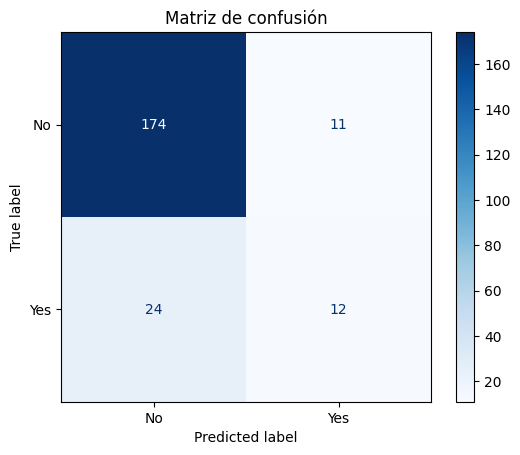

In [39]:
from sklearn.metrics import confusion_matrix

# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Matriz de confusión
cm = confusion_matrix(y_test_real, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

disp.plot(cmap='Blues')

plt.title('Matriz de confusión')

plt.show()



# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

En el contexto del problema de rotación de personal:

* **VP:** Empleados que realmente abandonaron la empresa y el modelo predijo correctamente como "Yes".

* **VN:** Empleados que permanecieron en la empresa y el modelo predijo correctamente como "No".

* **FP:** Empleados que realmente permanecieron en la empresa, pero el modelo predijo incorrectamente que abandonarían la empresa.

* **FN:** Empleados que realmente abandonaron la empresa, pero el modelo predijo incorrectamente que permanecerían en la organización.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

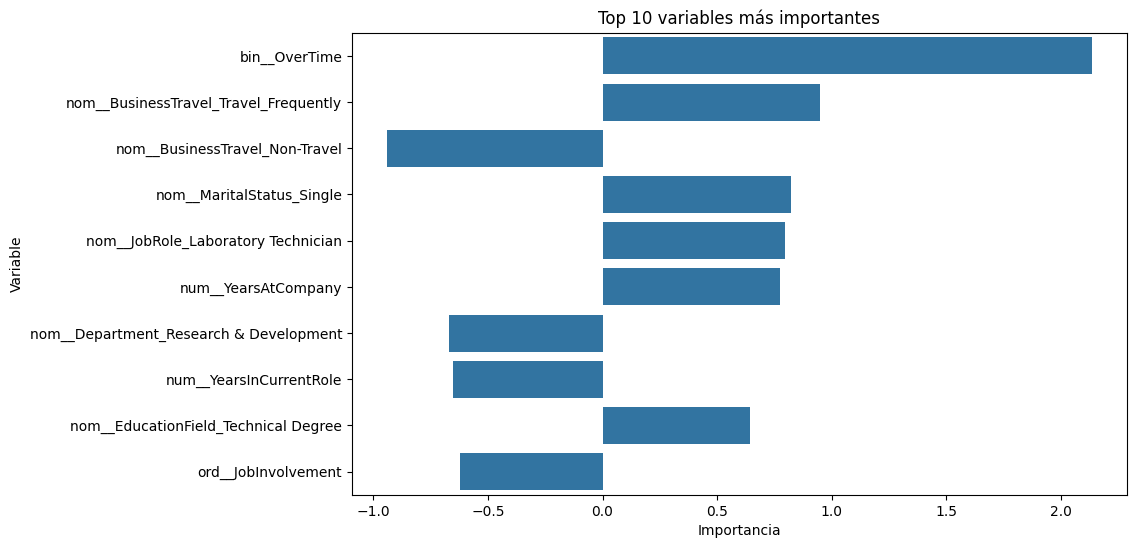

In [40]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# Obtener nombres de variables
feature_names = resultado_malla.best_estimator_ \
    .named_steps['ct'] \
    .get_feature_names_out()

# Obtener coeficientes
coeficientes = resultado_malla.best_estimator_ \
    .named_steps['modelo'] \
    .coef_[0]

# DataFrame importancia
importancia = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': coeficientes
})

# Valor absoluto
importancia['Abs'] = importancia['Importancia'].abs()

# Ordenar
importancia = importancia.sort_values(
    by='Abs',
    ascending=False
).head(10)

# Gráfico
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancia,
    x='Importancia',
    y='Variable'
)

plt.title('Top 10 variables más importantes')

plt.show()

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

- El análisis de importancia permite identificar las variables con mayor influencia en la predicción de rotación de personal.

- Variables como OverTime, MonthlyIncome, Age y JobSatisfaction presentan una relación importante con Attrition.

- Los coeficientes positivos indican un aumento en la probabilidad de abandono, mientras que coeficientes negativos indican menor probabilidad de rotación.

- Este análisis puede ayudar a recursos humanos a identificar factores críticos relacionados con la permanencia de los empleados en la empresa.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quién de los colaboradores una empresa estará abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) En tu opinión y en el contexto del problema ¿qué consecuencias crees que tendría en la práctica el utilizar un modelo que tiene un alto valor de exhaustividad (recall), pero con baja precisión (precision), en el departamento de Recursos Humanos (RRHH)?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, podemos suponer que se lo vas a comunicar a los directivos de tu empresa o al personal de RRHH.**

* **d) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

### a)

Si un modelo identifica colaboradores con alta probabilidad de abandonar la empresa, esta información debe utilizarse de manera ética y responsable. El objetivo debería ser mejorar el ambiente laboral, identificar problemas organizacionales y generar estrategias de retención, evitando cualquier tipo de discriminación o sanción hacia los empleados. Además, es importante proteger la privacidad de los colaboradores y garantizar el uso confidencial de la información.

---

### b)

Un modelo con alto recall pero baja precisión identificaría a la mayoría de empleados que realmente abandonarían la empresa, pero también generaría muchos falsos positivos. En la práctica, esto podría provocar que RRHH dedique recursos y tiempo a colaboradores que realmente no planean abandonar la organización. Sin embargo, podría ser útil cuando el objetivo principal sea prevenir la pérdida de talento importante.

---

### c)

Los resultados podrían comunicarse indicando que el modelo ayuda a detectar patrones relacionados con la rotación de personal utilizando información histórica de empleados. También se podría explicar que variables como horas extra, satisfacción laboral o ingresos tienen influencia en la permanencia de los colaboradores. Finalmente, se debe aclarar que el modelo es una herramienta de apoyo para la toma de decisiones y no un reemplazo del criterio humano.

---

### d)

En esta actividad se aplicaron técnicas de análisis de datos y aprendizaje automático para estudiar el problema de rotación de personal. Se realizaron procesos de limpieza, transformación, análisis exploratorio y entrenamiento de diferentes modelos. El modelo LASSO obtuvo el mejor desempeño utilizando la métrica accuracy. Además, la actividad permitió comprender la importancia de la validación cruzada, la selección de variables y las implicaciones éticas relacionadas con el uso de modelos predictivos en recursos humanos.


#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<